# Fraud Detection — Version 3

**Question V1/V2 never asked: is there any signal in these features at all?**

| | |
|---|---|
| **Data** | `MyBank.csv`, 138,752 transactions, 3,963 frauds (2.86%) |
| **Bottom line** | V1/V2's ≈98% scores are evaluation artifacts. Done correctly, every model scores AUC ≈ 0.50 (chance). |
| **Why** | (1) `TransactionKey` is a perfect label leak, (2) V1/V2 oversampled before splitting, (3) the features carry no detectable signal. |

This notebook is the readable walkthrough. Light checks run live; heavy experiments (permutation tests, power check, tuning) are loaded from `reports/`,
and each one has a numbered script in `scripts/` that regenerates it. All logic lives in `src/fd`, nothing is duplicated here.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score
warnings.filterwarnings("ignore")

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from fd.data import load_raw, RAW_PATH
from fd.features import build_features

TABLES, FIGS = ROOT / "reports" / "tables", ROOT / "reports" / "figures"
show = lambda name: display(Image(filename=str(FIGS / name)))
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
print("raw data:", RAW_PATH)

raw data: D:\CODING\Others\Capstones_CLOSED\Fraud-Detection\Version 1\MyBank.csv


## 1. Audit the raw data

In [2]:
raw = load_raw()
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} cols | frauds: {raw.Fraud.sum():,} ({raw.Fraud.mean():.2%}) | duplicate rows: {raw.duplicated().sum()}")
miss = raw.isna().sum(); miss = miss[miss > 0]
pd.DataFrame({"n_missing": miss, "pct": (miss / len(raw)).map("{:.1%}".format),
              "fraud_rate_if_missing": [raw.Fraud[raw[c].isna()].mean() for c in miss.index]}).round(4)

138,752 rows x 27 cols | frauds: 3,963 (2.86%) | duplicate rows: 0


,n_missing,pct,fraud_rate_if_missing
AreaCode,12,0.0%,0.0833
EmailUpdateDate,26,0.0%,0.0000
LastLong,24389,17.6%,0.0279
LastLat,24231,17.5%,0.0271
CurrentLat,24379,17.6%,0.0276
IsOldDevice,4070,2.9%,0.0319
WebSessionRetail,4038,2.9%,0.0248
MainEntityUse,4080,2.9%,0.0235


Missingness is not informative: for every column with > 4,000 missing rows the fraud rate is 2.4–3.2% whether the value is present or not
(the two columns with 12 and 26 missing rows are too small to read). Other quirks (`TimeZone` = 999 sentinel, `WebSessionRetail` constant, 1,000+ profile updates dated
*after* the transaction, a 9,820-row `AddressUpdateDate` that looks like a system default) are in `reports/tables/audit.txt`.

## 2. `TransactionKey` is a perfect label leak

fraud keys     134,790 .. 138,752
non-fraud keys 1 .. 134,789
AUC of TransactionKey alone: 1.0


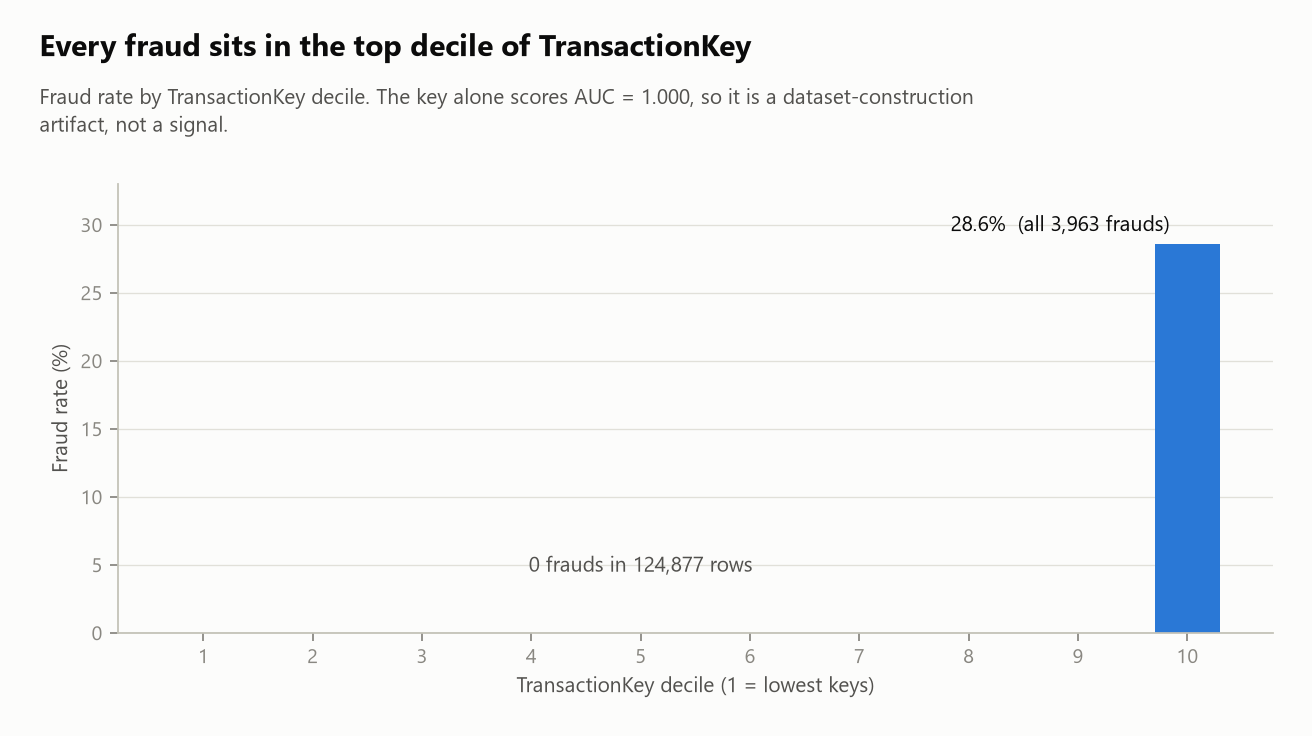

In [3]:
fk, nk = raw.TransactionKey[raw.Fraud == 1], raw.TransactionKey[raw.Fraud == 0]
print(f"fraud keys     {fk.min():,} .. {fk.max():,}")
print(f"non-fraud keys {nk.min():,} .. {nk.max():,}")
print("AUC of TransactionKey alone:", roc_auc_score(raw.Fraud, raw.TransactionKey))
show("fig1_key_leak.png")

Every fraud is one of the last 3,963 keys, so the key alone separates the classes perfectly. It is a dataset-construction artifact, not something a bank could know at transaction time.
V1/V2 dropped it, but any model that keeps it looks perfect. **It is excluded from every V3 feature** (`build_features` never reads it, and the final evaluation asserts that).

## 3. Label-free feature engineering

In [4]:
X, y = build_features(raw)
assert "TransactionKey" not in X.columns
cats = X.select_dtypes("category").columns.tolist()
print(f"{X.shape[1]} features ({len(cats)} categorical, {X.shape[1]-len(cats)} numeric) | {len(y):,} rows | {y.sum():,} frauds")
groups = {
    "raw numerics + sentinel fix": ["V1CF","V2CF","V3CF","V4CF","V5CF","AreaCode","MainEntityUse","IsOldDevice","TimeZone","tz_sentinel"],
    "missingness flags":  [c for c in X.columns if c.endswith("_isna") or c in ("n_missing","partial_geo","email_date_isna")],
    "geo":                ["LastLong","LastLat","CurrentLong","CurrentLat","geo_dist_km","geo_moved","tz_long_gap","areacode_eq_v4","v4_zero","v5_zero"],
    "time / profile age": [c for c in X.columns if c.startswith(("hour","dow","is_weekend","days_since","in_tail","addr_","email_")) and c not in ("addr_n","email_n","addr_org_n")],
    "velocity / entity counts": ["addr_n","email_n","pair_n","txn_same_sec_n","org_n","addr_org_n"],
    "categoricals": cats,
}
for k, v in groups.items(): print(f"{k:28s} {len(v):2d}  {', '.join(v[:6])}{' ...' if len(v) > 6 else ''}")

66 features (10 categorical, 56 numeric) | 138,752 rows | 3,963 frauds
raw numerics + sentinel fix  10  V1CF, V2CF, V3CF, V4CF, V5CF, AreaCode ...
missingness flags            10  AreaCode_isna, LastLong_isna, LastLat_isna, CurrentLat_isna, IsOldDevice_isna, WebSessionRetail_isna ...
geo                          10  LastLong, LastLat, CurrentLong, CurrentLat, geo_dist_km, geo_moved ...
time / profile age           21  hour, hour_sin, hour_cos, dow, is_weekend, days_since_start ...
velocity / entity counts      6  addr_n, email_n, pair_n, txn_same_sec_n, org_n, addr_org_n
categoricals                 10  ConnectionOrg, ConnectionType, ConnectionSpeed, V6CF, channel, webSessOS ...


Everything here is computed **without the label**, so it is safe before any split. Anything that would use the label (target encoding, resampling, imputation fit) belongs inside cross-validation folds.

## 4. Single-feature tests

In [5]:
from scipy import stats
rows = []
for c in X.columns.difference(cats):
    x = X[c].astype(float); m = x.notna().to_numpy()
    if x[m].nunique() < 2: continue
    _, p = stats.mannwhitneyu(x[m][y[m] == 1], x[m][y[m] == 0], alternative="two-sided")
    a = roc_auc_score(y[m], x[m]); rows.append((c, int(m.sum()), a, p))
uni = pd.DataFrame(rows, columns=["feature", "n", "auc", "p"]).sort_values("p").reset_index(drop=True)
n = len(uni); q = np.minimum.accumulate((uni.p.to_numpy() * n / np.arange(1, n + 1))[::-1])[::-1]; uni["q_bh"] = np.minimum(q, 1)
n1, n0 = y.sum(), (1 - y).sum(); se = np.sqrt((n1 + n0 + 1) / (12 * n1 * n0))
print(f"{n} numeric features | AUC range {uni.auc.min():.3f}..{uni.auc.max():.3f} | p<0.05: {(uni.p<.05).sum()} (chance ~{.05*n:.0f}) | pass FDR (q<0.05): {(uni.q_bh<.05).sum()}")
print(f"null SE of AUC = {se:.4f} -> smallest detectable |AUC-0.5| ~ {1.96*se:.3f} (alpha .05), {2.8*se:.3f} (80% power)")
uni.head(8).round(4)

56 numeric features | AUC range 0.491..0.512 | p<0.05: 2 (chance ~3) | pass FDR (q<0.05): 0
null SE of AUC = 0.0047 -> smallest detectable |AUC-0.5| ~ 0.009 (alpha .05), 0.013 (80% power)


,feature,n,auc,p,q_bh
0,LastLong,114363,0.5117,0.0223,0.5997
1,n_missing,138752,0.4916,0.0455,0.5997
2,MainEntityUse_isna,138752,0.4973,0.0501,0.5997
3,TimeZone,138748,0.4915,0.0542,0.5997
4,pair_n,138752,0.4980,0.0567,0.5997
5,partial_geo,138752,0.4924,0.0643,0.5997
6,org_n,138752,0.4922,0.0916,0.6725
7,v5_zero,138752,0.4973,0.1096,0.6725


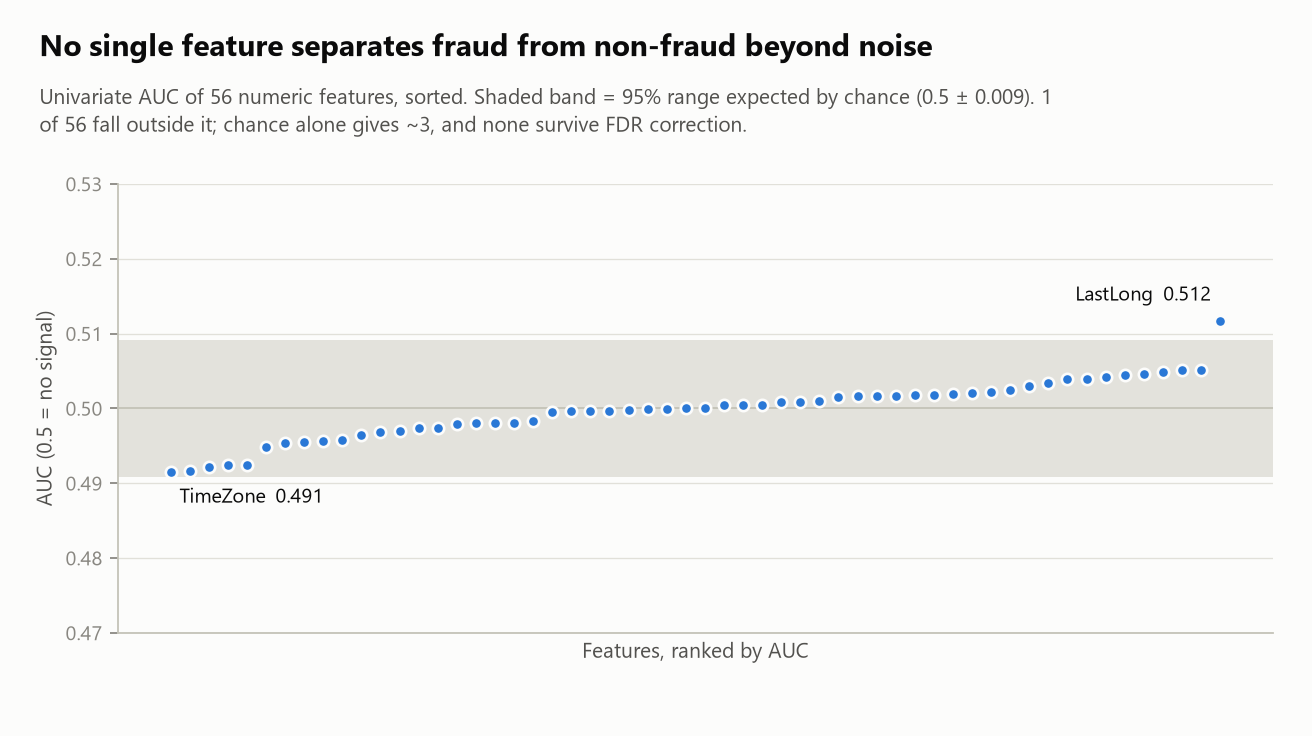

In [6]:
show("fig2_univariate_auc.png")

Categorical levels (n ≥ 200) tested against the base rate, with Benjamini–Hochberg correction across all 134 levels:

In [7]:
lv = pd.read_csv(TABLES / "categorical_levels.csv")
print(f"levels tested: {len(lv)} | nominal p<0.05: {(lv.p<.05).sum()} (chance ~{.05*len(lv):.0f}) | pass FDR: {(lv.q_bh<.05).sum()}")
lv.head(6)[["col", "level", "n", "frauds", "rate", "lift", "p", "q_bh"]].round(4)

levels tested: 134 | nominal p<0.05: 6 (chance ~7) | pass FDR: 0


,col,level,n,frauds,rate,lift,p,q_bh
0,ConnectionOrg,comcast cable communications ip services,892,42,0.0471,1.6485,0.0024,0.3153
1,V6CF,org,1315,52,0.0395,1.3845,0.0203,0.9115
2,Region,northeast,23185,717,0.0309,1.0827,0.0316,0.9115
3,State,new york,21448,665,0.0310,1.0856,0.0330,0.9115
4,ConnectionOrg,wide open west,310,3,0.0097,0.3388,0.0400,0.9115
5,ConnectionType,consumer satellite,287,14,0.0488,1.7079,0.0491,0.9115


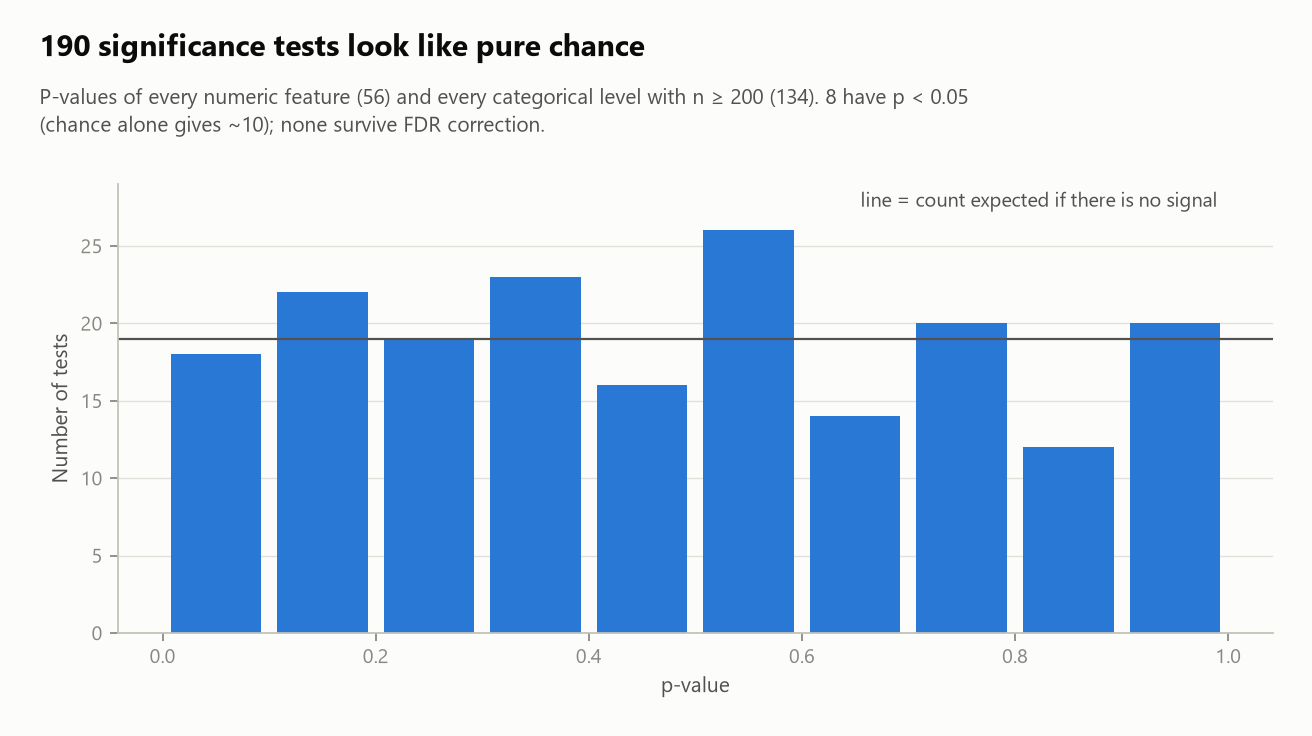

In [8]:
show("fig3_pvalues.png")

Nothing survives correction, and the p-values are roughly uniform, which is what pure noise looks like.

**Do frauds cluster within an account?** If `Fraud` were driven by compromised accounts, frauds would share address/email timestamps or coordinates more than chance allows.
Permutation test (2,000 label shuffles each; `scripts/03_deep_tests.py`):

In [9]:
pd.read_csv(TABLES / "entity_clustering.csv").round(3)

,key,n_groups,rows_in_multi,obs_fraud_pairs,null_mean,null_sd,z,p
0,AddressUpdateDate,66794,106058,31016.0,39390.262,4360.637,-1.920,0.977
1,EmailUpdateDate,66942,105948,19782.0,21647.432,2527.765,-0.738,0.773
2,Address+Email,137144,2394,85.0,122.124,53.839,-0.690,0.737
3,TransactionDateTime(sec),82445,93597,70.0,68.020,8.494,0.233,0.422
4,Last lat/long,86051,62230,2716.0,2426.828,246.797,1.172,0.120
5,Current long,3603,137973,194685.0,189490.933,8844.693,0.587,0.271
6,ConnectionOrg(raw),7620,135999,273612.0,285072.469,9320.822,-1.230,0.889
7,AreaCode+V4+V5,59861,95594,1328.0,1343.544,114.104,-0.136,0.529
8,MainEntityUse,4659,134654,56010.0,55142.558,1556.232,0.557,0.290
9,AddressUpdateDate [groups 2-50],66794,95940,109.0,96.281,10.140,1.254,0.117


All p-values are between 0.12 and 0.98, so there is no clustering. (The uncapped `AddressUpdateDate` is dominated by one 9,820-row default value, hence the capped "groups 2–50" rows.)

## 5. Multivariate signal: cross-validated LightGBM vs a shuffled-label null

In [10]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

def cv_auc(X, y, seed=42):
    oof = np.zeros(len(y))
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.03, num_leaves=31, min_child_samples=100, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.7, reg_lambda=5.0, n_jobs=-1, verbose=-1, random_state=0).fit(X.iloc[tr], y[tr])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
    return roc_auc_score(y, oof)

real = cv_auc(X, y)
rng = np.random.default_rng(0)
null = np.array([cv_auc(X, rng.permutation(y), seed=i) for i in range(5)])
print(f"real labels   : CV AUC = {real:.4f}")
print(f"shuffled (x5) : CV AUC = {null.mean():.4f} +- {null.std():.4f}  (range {null.min():.4f}..{null.max():.4f})")

real labels   : CV AUC = 0.4987
shuffled (x5) : CV AUC = 0.5000 +- 0.0062  (range 0.4895..0.5078)


In [11]:
# the full 20-shuffle run (scripts/02_signal_test.py 20)
print("\n".join(l for l in (TABLES / "signal_test.log").read_text().splitlines() if l.startswith("rounds=")))

rounds=25: real AUC 0.5022 | null AUC mean 0.4993 sd 0.0079 max 0.5135 | p=0.381 | real PR 0.0289 null PR 0.0286
rounds=50: real AUC 0.4996 | null AUC mean 0.4988 sd 0.0076 max 0.5131 | p=0.476 | real PR 0.0288 null PR 0.0285
rounds=100: real AUC 0.5009 | null AUC mean 0.4989 sd 0.0080 max 0.5122 | p=0.429 | real PR 0.0289 null PR 0.0285
rounds=200: real AUC 0.4987 | null AUC mean 0.4983 sd 0.0078 max 0.5132 | p=0.571 | real PR 0.0287 null PR 0.0285
rounds=400: real AUC 0.4988 | null AUC mean 0.4978 sd 0.0072 max 0.5115 | p=0.571 | real PR 0.0288 null PR 0.0285


The real labels sit inside the null: 66 features, gradient boosting, and nothing above chance (PR-AUC 0.0288 vs a 0.0286 base rate).

## 6. Could the pipeline have seen a signal if there were one?
I planted signals of known strength in the real features, generating labels from a logistic model, and re-ran the same CV (`scripts/04_power_check.py`).

In [12]:
pd.read_csv(TABLES / "power_check.csv")

,planted_lambda,oracle_auc,lgbm_cv_auc,recovered_frac
0,0.00,0.5000,0.5001,NaN
1,0.03,0.5096,0.5045,0.4704
2,0.05,0.5146,0.5103,0.7070
3,0.08,0.5230,0.5071,0.3090
4,0.12,0.5352,0.5127,0.3613
5,0.20,0.5580,0.5299,0.5151
6,0.40,0.6150,0.5888,0.7723


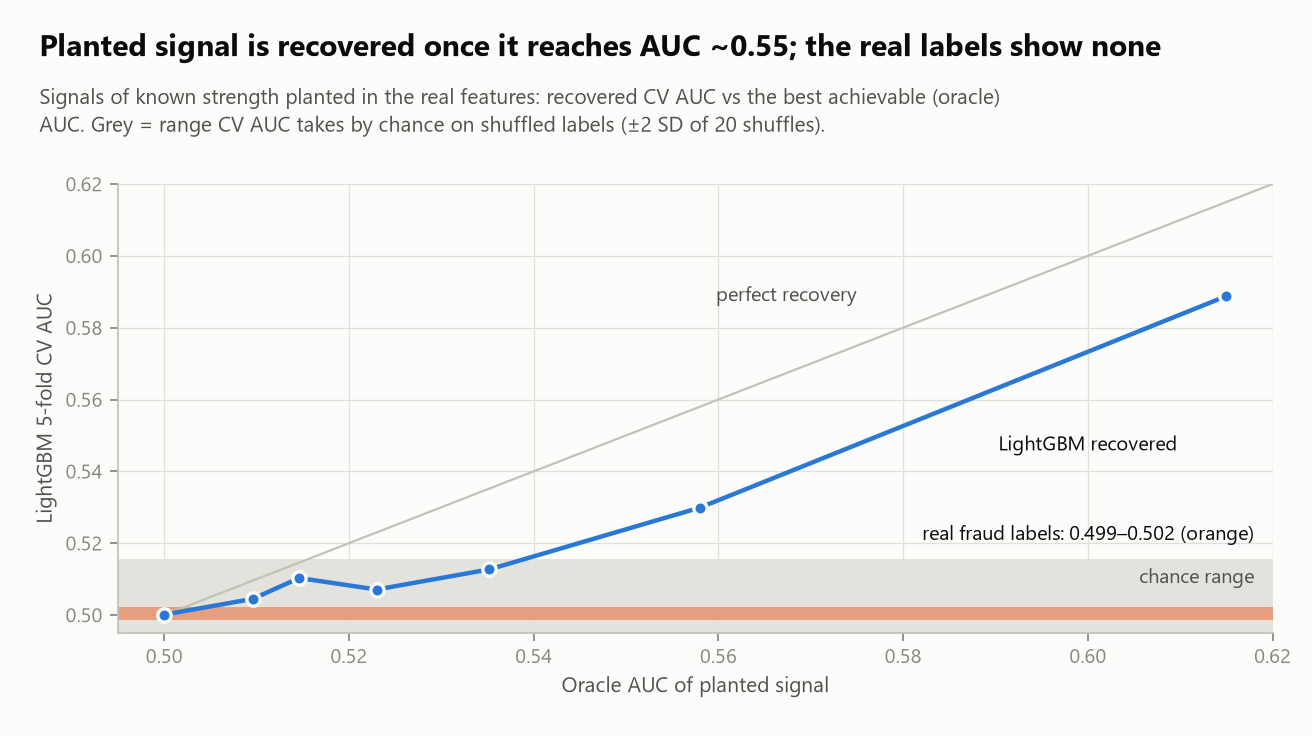

In [13]:
show("fig5_power.png")

Planted signal is recovered clearly from oracle AUC ≈ 0.55 upward. So the null on the real labels is a property of the data, not a bug in the pipeline. Anything weaker than that would be
operationally worthless (at AUC 0.51–0.53 a review queue barely beats random).

## 7. Why V1/V2 looked great: the same data, evaluated two ways
V2 ran SMOTE on **all** rows and then split, so synthetic neighbours of test rows sit in the training set. V1 did the same with random oversampling (exact copies of test rows in training).
Below: V2's protocol vs the correct one (split first, SMOTE on train only), on V2's own dataset with the same XGBoost.

In [14]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier

V2_CSV = ROOT.parent / "Version 2" / "FD-Dataset-2.csv"
def xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=0, tree_method="hist")
def score(name, m, Xtr, ytr, Xte, yte):
    p = m.fit(Xtr, ytr).predict_proba(Xte)[:, 1]; pred = (p >= .5).astype(int)
    return dict(protocol=name, test_rows=len(yte), test_frauds=int(yte.sum()), auc=roc_auc_score(yte, p), precision=precision_score(yte, pred, zero_division=0),
                recall=recall_score(yte, pred), f1=f1_score(yte, pred))

if V2_CSV.exists():
    d2 = pd.read_csv(V2_CSV); X2, y2 = d2.drop(columns="Fraud"), d2.Fraud.to_numpy()
    Xs, ys = SMOTE(random_state=0).fit_resample(X2, y2)                       # LEAKY: resample everything, then split
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.3, random_state=0)
    a = score("V2: SMOTE(all) -> split", xgb(), Xtr, ytr, Xte, yte)
    Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
    Xs, ys = SMOTE(random_state=0).fit_resample(Xtr, ytr)                      # CORRECT: split first, resample train only
    c = score("correct: split -> SMOTE(train)", xgb(), Xs, ys, Xte, yte)
    live = pd.DataFrame([a, c]).round(4)
else:
    live = pd.read_csv(TABLES / "leakage_demo.csv").iloc[[0, 2]].rename(columns={"test_n": "test_rows", "test_pos": "test_frauds"})[["protocol", "test_rows", "test_frauds", "auc", "precision", "recall", "f1"]].round(4)
live

,protocol,test_rows,test_frauds,auc,precision,recall,f1
0,V2: SMOTE(all) -> split,80654,40413,0.9862,0.9997,0.9701,0.9847
1,correct: split -> SMOTE(train),27675,790,0.4944,0.0000,0.0000,0.0000


In [15]:
pd.read_csv(TABLES / "leakage_demo.csv")[["protocol", "auc", "precision", "recall", "f1"]].round(3)

,protocol,auc,precision,recall,f1
0,A V2: SMOTE(all) -> split,0.986,1.000,0.970,0.985
1,B V1: ROS(all) -> test on original 20%,0.972,0.180,0.938,0.302
2,C correct: split -> SMOTE(train),0.494,0.000,0.000,0.000
3,D correct: split -> scale_pos_weight,0.486,0.029,0.129,0.048
4,E key leak: + TransactionKey,1.000,0.949,0.976,0.962
5,"E' same, key removed",0.499,0.029,0.340,0.053


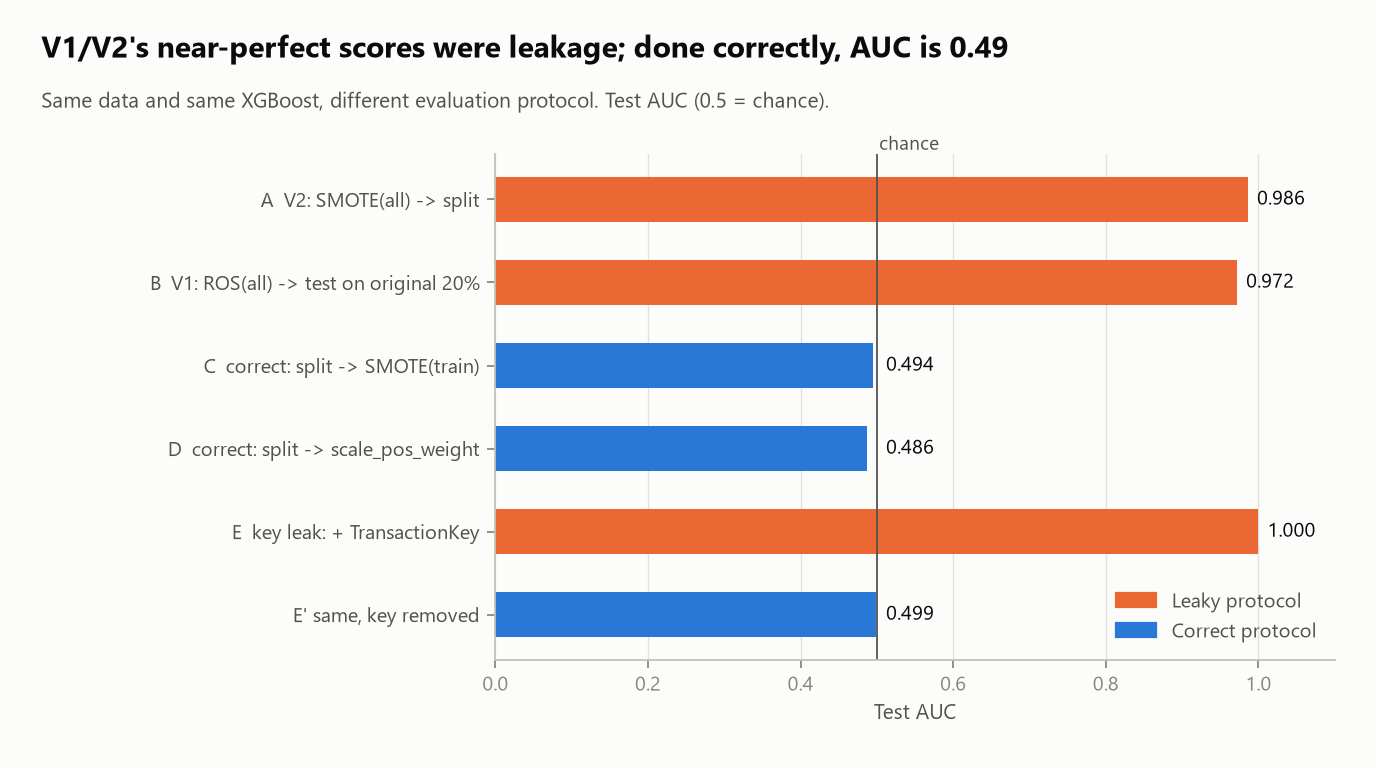

In [16]:
show("fig4_protocols.png")

(The leaky protocol's test set is balanced by SMOTE, so its precision/F1 are not comparable to the others; AUC is the fair column.)
V1's pickled Optuna model (`xgboostclf_optuna.pkl`, 99.7% recall) was scored on rows it had been trained on; V2's own "normal data" cells already showed test recall ≈ 0% for every model.

## 8. Leak-safe final evaluation
Locked stratified 20% test set (793 frauds), 5-fold out-of-fold CV on the remaining 80%, class imbalance handled by weighting only, no resampling anywhere near the test rows (`scripts/07_final_evaluation.py`).

In [17]:
fe = pd.read_csv(TABLES / "final_evaluation.csv")
out = fe[["model", "cv_auc", "test_auc", "test_auc_lo", "test_auc_hi", "test_pr_auc", "test_pr_lo", "test_pr_hi"]].round(4)
print(f"test base rate (= PR-AUC of a coin flip): {fe.base_rate.iloc[0]:.4f}")
out

test base rate (= PR-AUC of a coin flip): 0.0286


,model,cv_auc,test_auc,test_auc_lo,test_auc_hi,test_pr_auc,test_pr_lo,test_pr_hi
0,base-rate (dummy),0.5000,0.5000,0.5000,0.5000,0.0286,0.0265,0.0306
1,logistic L2,0.4931,0.4972,0.4741,0.5174,0.0290,0.0264,0.0331
2,lightgbm (regularised),0.4945,0.4899,0.4678,0.5113,0.0282,0.0256,0.0317
3,xgboost (scale_pos_weight),0.4963,0.4960,0.4745,0.5182,0.0287,0.0262,0.0329


Every model is at chance and every confidence interval contains 0.5. (A cross-validated AUC slightly *below* 0.5 is the known bias of stratified CV when there is no signal.)
Also note that "lift in the top 1%" is noise at this size: the constant-score dummy scores 1.38× only because a 1% queue is 278 rows.

## 9. Does tuning help? (Optuna, real vs shuffled labels)

In [18]:
pd.read_csv(TABLES / "tuning_noise.csv").round(4)

,labels,n_trials,best_cv_auc,median_trial_cv_auc,locked_test_auc,locked_test_pr_auc,test_base_rate
0,real,40,0.5073,0.4985,0.5058,0.0303,0.0286
1,permuted,40,0.5021,0.4982,0.5028,0.0296,0.0286


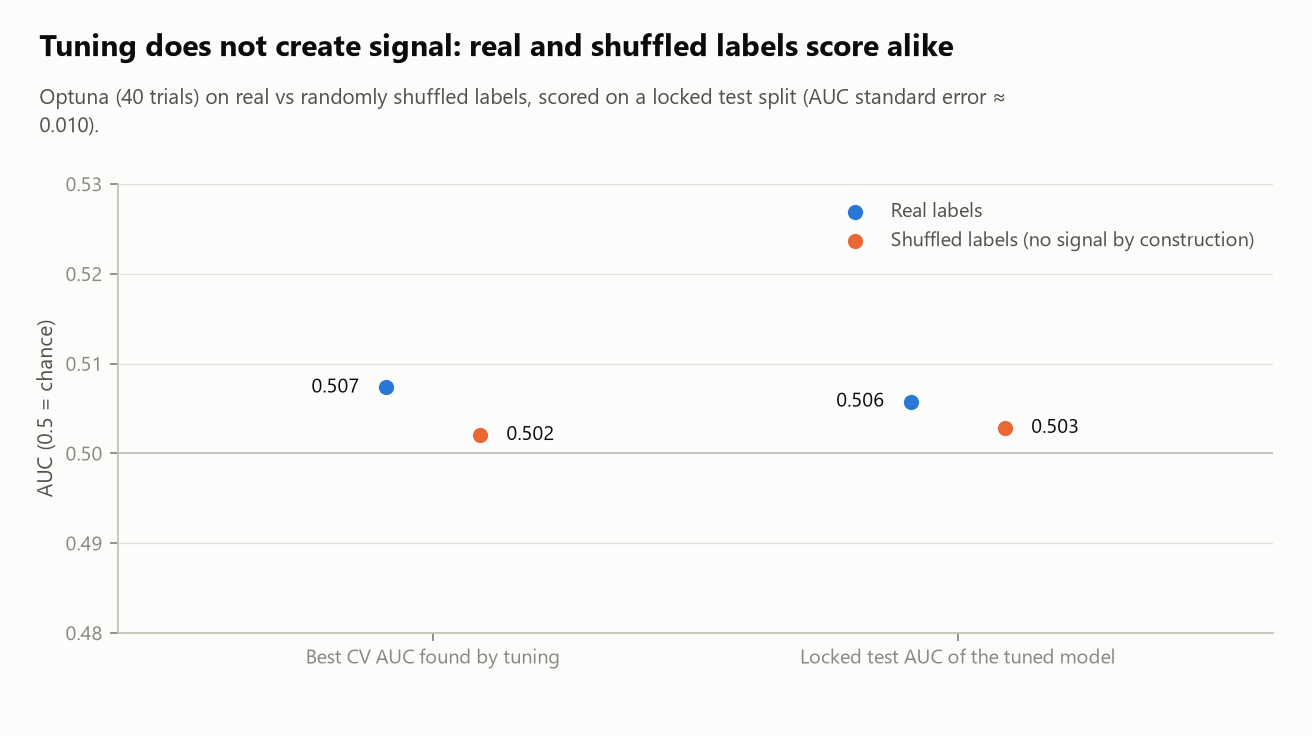

In [19]:
show("fig6_tuning_noise.png")

Tuning 40 trials on the real labels gives a locked-test AUC of 0.506; on **shuffled** labels it gives 0.503. Both are well inside the test set's standard error (≈ 0.010).

## 10. Conclusions and what to do next
1. **V1/V2's headline scores were leakage.** The same data evaluated correctly gives AUC ≈ 0.49–0.50.
2. **`TransactionKey` leaks the label perfectly** and must never be a feature.
3. **These features contain no detectable fraud signal**: single-feature tests, entity clustering, a gradient-boosting model and hyper-parameter tuning all land on chance, and the pipeline demonstrably detects planted signal (from oracle AUC ≈ 0.55).
4. **There is nothing to improve on this dataset.** More modelling would only manufacture leakage.

**What would change that**
* Ask the data owner how `Fraud` and `TransactionKey` were generated. The pattern suggests synthetic or shuffled labels (a hypothesis, not verified).
* Real fraud modelling needs the columns that are missing here: transaction amount, merchant, account/card/device ID and label delay.
* With an account ID: `GroupKFold` by account, a time-based hold-out, and velocity features over rolling windows.
* Keep the protocol in `src/fd`: split first, sampling only inside training folds, PR-AUC and precision@k rather than accuracy, thresholds set from review cost.
* Frame the capstone as a **data-validity case study**: it is a stronger story than a 98% score that collapses under a correct split.